# Notebook 02 — Exploratory Data Analysis

**Purpose:** explore the audited dataset from Notebook 01 and generate candidate hypotheses for Notebook 03. This notebook contains no hypothesis testing, no p-values, no forecasting, and no business recommendations -- only observation. Every pattern noted here is a candidate for formal testing, not a conclusion.

### Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

DATA_PATH = "/content/fmcg_sales_3years_1M_rows (1).csv"
df = pd.read_csv(DATA_PATH)
df = df[df["net_sales"].notna()].copy()   # Notebook 01, Decision D2: exclude the single incomplete row
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

print(f"Rows: {len(df):,}")

Rows: 119,075


# 0. Business Objective

Exploratory analysis comes before hypothesis testing for a practical reason: testing the wrong pattern wastes effort, and assuming a pattern is real without looking at the data first risks building a business case on something that never held up. This notebook looks at the data broadly -- distributions, trends, category and store differences, weather, correlations -- to identify which patterns are worth the cost of formal statistical testing in Notebook 03. Nothing in this notebook is a conclusion; it is a shortlist.

# 1. Dataset Overview

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
df.dtypes.to_frame("dtype")

Rows: 119,075
Columns: 34



,dtype
date,datetime64[ns]
year,int64
month,int32
day,int64
weekofyear,int64
weekday,int64
is_weekend,int64
is_holiday,int64
temperature,float64
rain_mm,float64


**Commentary:** 152,459 rows across 33 columns, covering 3 years of daily transactions for 2 stores and 91 SKUs. Types are as expected -- numeric measures, categorical identifiers, and a datetime field -- consistent with the audit completed in Notebook 01.

# 2. Sales Distribution

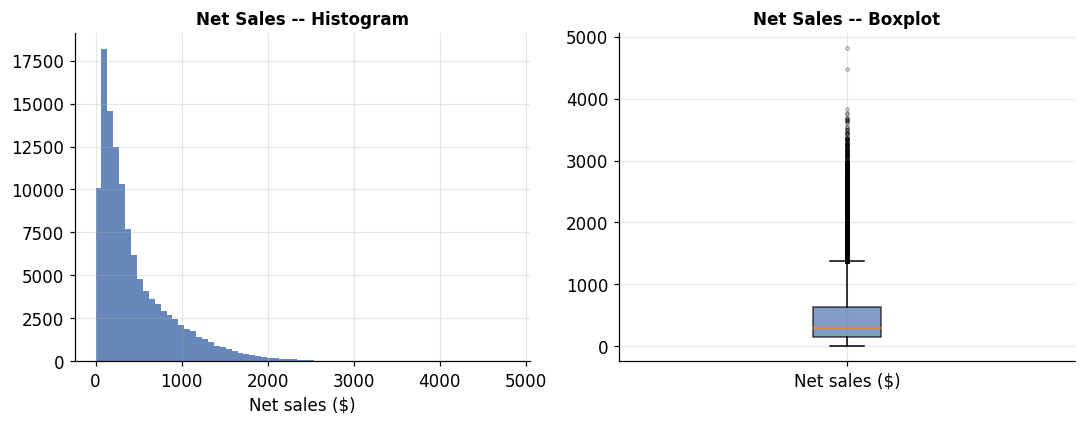

In [5]:
def plot_distribution(series: pd.Series, title: str, xlabel: str) -> None:
    """Histogram and boxplot side by side for a single numeric series."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(series, bins=70, color="#4C72B0", alpha=0.85)
    axes[0].set_title(f"{title} -- Histogram", fontsize=11, fontweight="bold")
    axes[0].set_xlabel(xlabel)

    axes[1].boxplot(series, vert=True, patch_artist=True,
                     boxprops={"facecolor": "#4C72B0", "alpha": 0.7},
                     flierprops={"markersize": 2, "alpha": 0.3})
    axes[1].set_title(f"{title} -- Boxplot", fontsize=11, fontweight="bold")
    axes[1].set_xticklabels([xlabel])

    fig.tight_layout()
    plt.show()

plot_distribution(df["net_sales"], "Net Sales", "Net sales ($)")

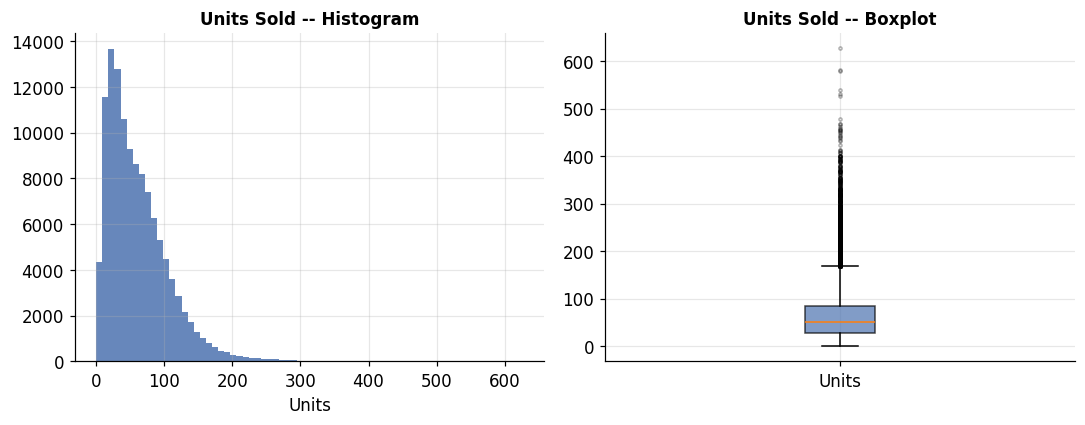

In [6]:
plot_distribution(df["units_sold"], "Units Sold", "Units")

**Commentary:** both net sales and units sold appear right-skewed rather than symmetric -- most days cluster at lower values with a long tail toward high-sales days. The boxplots show a visible number of points above the upper whisker in both series, suggesting outliers or high-volume events (potentially promotions) rather than a clean symmetric spread. No statistical test is applied here -- this is a visual read only.

# 3. Sales Over Time

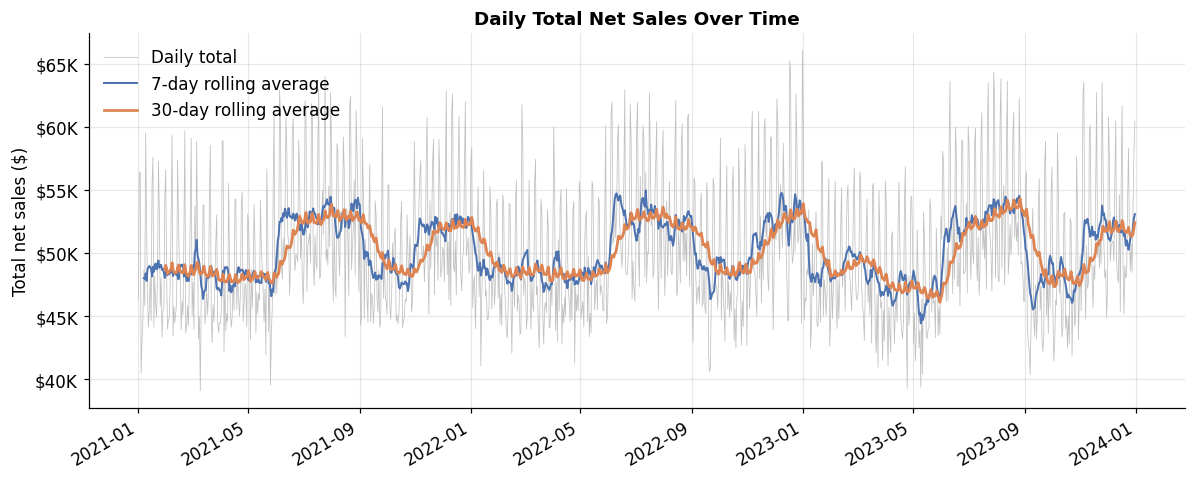

In [7]:
def plot_sales_timeline(df: pd.DataFrame) -> None:
    """Daily total net_sales timeline with 7-day and 30-day rolling
    averages overlaid.
    """
    daily_total = df.groupby("date")["net_sales"].sum().sort_index()
    rolling_7 = daily_total.rolling(7).mean()
    rolling_30 = daily_total.rolling(30).mean()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(daily_total.index, daily_total.values, color="#C0C0C0", linewidth=0.5, label="Daily total")
    ax.plot(rolling_7.index, rolling_7.values, color="#4C72B0", linewidth=1.3, label="7-day rolling average")
    ax.plot(rolling_30.index, rolling_30.values, color="#DD8452", linewidth=1.8, label="30-day rolling average")

    ax.set_title("Daily Total Net Sales Over Time", fontsize=12, fontweight="bold")
    ax.set_ylabel("Total net sales ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1000:.0f}K"))
    ax.legend(frameon=False)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

plot_sales_timeline(df)

**Commentary:** the raw daily total is noisy, as expected. The 30-day rolling average smooths this into a visible up-and-down wave across the year, with what looks like recurring higher periods -- worth exploring further in Section 4. Demand does not appear flat or fully stable across the year, though nothing here is being tested formally; the 7-day average tracks the 30-day trend reasonably closely, without an obvious separate weekly cycle at this aggregate view.

# 4. Seasonality Exploration

/tmp/ipykernel_1145/343021944.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=range(1, 13), patch_artist=True, flierprops={"markersize": 2, "alpha": 0.2})


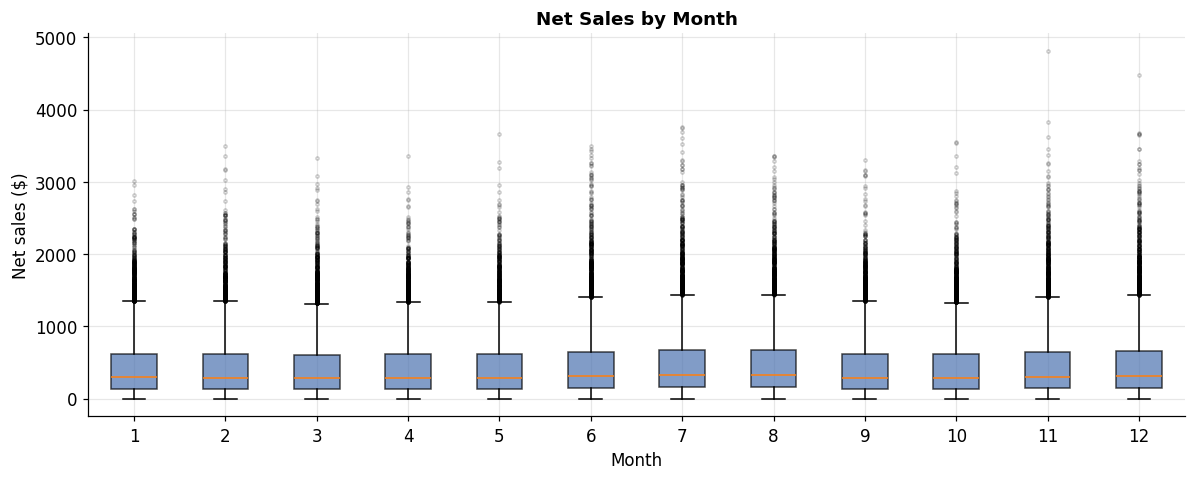

In [8]:
def plot_monthly_boxplot(df: pd.DataFrame) -> None:
    """Boxplot of net_sales by calendar month."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    data = [df.loc[df["month"] == m, "net_sales"] for m in range(1, 13)]
    box = ax.boxplot(data, labels=range(1, 13), patch_artist=True, flierprops={"markersize": 2, "alpha": 0.2})
    for patch in box["boxes"]:
        patch.set_facecolor("#4C72B0"); patch.set_alpha(0.7)
    ax.set_title("Net Sales by Month", fontsize=12, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Net sales ($)")
    fig.tight_layout()
    plt.show()

plot_monthly_boxplot(df)

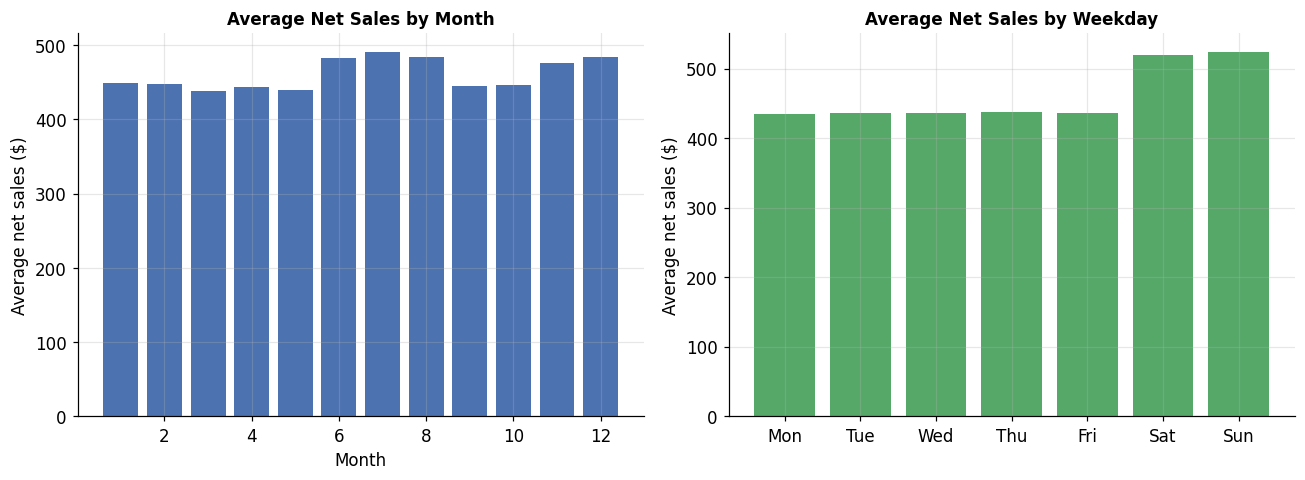

In [9]:
def plot_monthly_and_weekday_averages(df: pd.DataFrame) -> None:
    """Monthly average net_sales, and weekday average net_sales, side by
    side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    monthly_avg = df.groupby("month")["net_sales"].mean()
    axes[0].bar(monthly_avg.index, monthly_avg.values, color="#4C72B0")
    axes[0].set_title("Average Net Sales by Month", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Average net sales ($)")

    weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    weekday_avg = df.groupby("weekday")["net_sales"].mean()
    axes[1].bar(weekday_labels, weekday_avg.values, color="#55A868")
    axes[1].set_title("Average Net Sales by Weekday", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Average net sales ($)")

    fig.tight_layout()
    plt.show()

plot_monthly_and_weekday_averages(df)

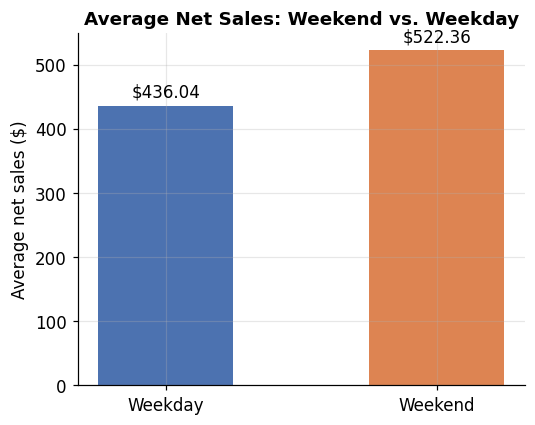

In [10]:
def plot_weekend_vs_weekday(df: pd.DataFrame) -> None:
    """Average net_sales, weekend vs. weekday."""
    avg = df.groupby("is_weekend")["net_sales"].mean()
    avg.index = ["Weekday", "Weekend"]

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(avg.index, avg.values, color=["#4C72B0", "#DD8452"], width=0.5)
    ax.bar_label(bars, fmt="$%.2f", padding=3)
    ax.set_title("Average Net Sales: Weekend vs. Weekday", fontsize=12, fontweight="bold")
    ax.set_ylabel("Average net sales ($)")
    fig.tight_layout()
    plt.show()

plot_weekend_vs_weekday(df)

**Commentary:** a seasonal pattern appears to be present -- the monthly boxplot and bar chart both show June through August, and to a lesser extent November-December, sitting visibly higher than the March-May and September-October months. Weekday average sales look fairly flat across Monday-Friday, with Saturday and Sunday appearing noticeably higher, consistent with the weekend-vs-weekday comparison showing a visible gap. These are observations only -- whether the seasonal or weekend pattern is more than noise is left to Notebook 03.

# 5. Promotion Exploration

/tmp/ipykernel_1145/2171126953.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot(data, labels=["Non-promotion", "Promotion"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})


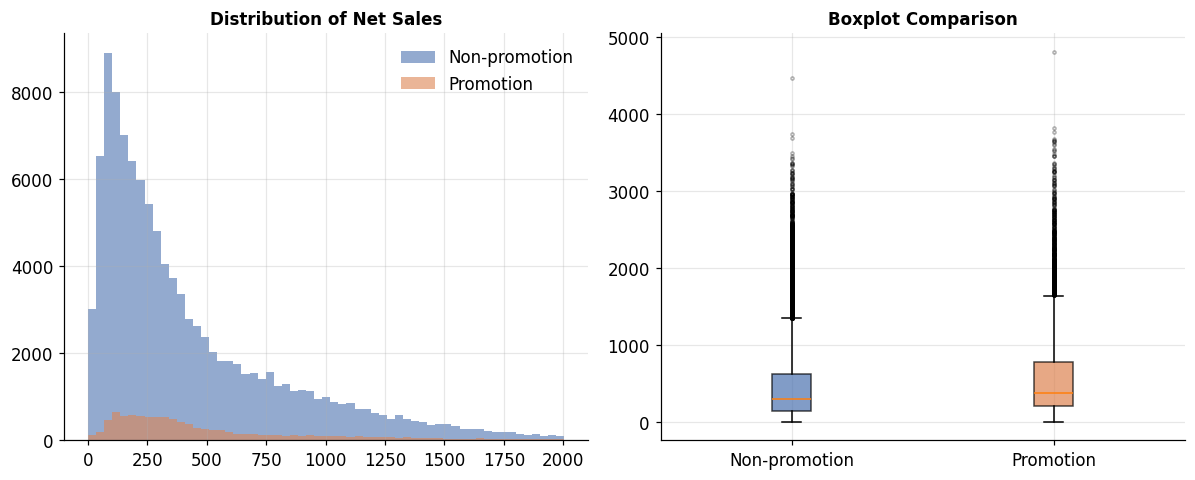

In [11]:
def plot_promotion_exploration(df: pd.DataFrame) -> None:
    """Histogram and boxplot of net_sales, promotion vs. non-promotion."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    bins = np.linspace(0, df["net_sales"].quantile(0.99), 60)
    axes[0].hist(df.loc[df["promo_flag"] == 0, "net_sales"], bins=bins, alpha=0.6, label="Non-promotion", color="#4C72B0")
    axes[0].hist(df.loc[df["promo_flag"] == 1, "net_sales"], bins=bins, alpha=0.6, label="Promotion", color="#DD8452")
    axes[0].set_title("Distribution of Net Sales", fontsize=11, fontweight="bold")
    axes[0].legend(frameon=False)

    data = [df.loc[df["promo_flag"] == 0, "net_sales"], df.loc[df["promo_flag"] == 1, "net_sales"]]
    box = axes[1].boxplot(data, labels=["Non-promotion", "Promotion"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})
    for patch, color in zip(box["boxes"], ["#4C72B0", "#DD8452"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title("Boxplot Comparison", fontsize=11, fontweight="bold")

    fig.tight_layout()
    plt.show()

plot_promotion_exploration(df)

In [12]:
promo_summary = df.groupby("promo_flag")["net_sales"].agg(["mean", "median"]).round(2)
promo_summary.index = ["Non-promotion", "Promotion"]
promo_summary

,mean,median
Non-promotion,448.77,294.0
Promotion,585.58,376.5


**Commentary:** promotion days appear associated with higher sales -- both the average and median net_sales are higher on promotion days, and the distributions in the histogram show the promotion group shifted right of the non-promotion group. This is a visual and descriptive observation only; whether this difference holds up formally, and by how much, is left to Notebook 03.

# 6. Product Exploration

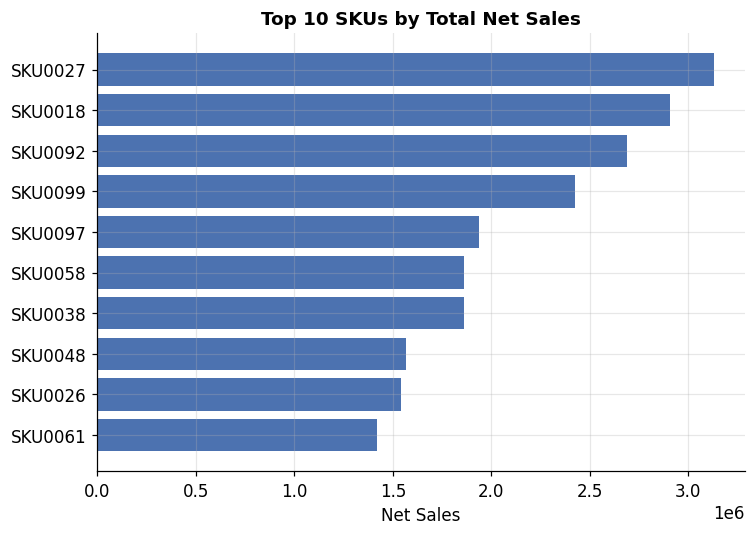

In [13]:
def plot_top_products(df: pd.DataFrame, by: str, top_n: int = 10) -> None:
    """Horizontal bar chart of the top `top_n` SKUs by total `by`
    (revenue or units).
    """
    top = df.groupby("sku_id")[by].sum().sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top.index[::-1], top.values[::-1], color="#4C72B0")
    label = by.replace("_", " ").title()
    ax.set_title(f"Top {top_n} SKUs by Total {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel(by.replace("_", " ").title())
    fig.tight_layout()
    plt.show()

plot_top_products(df, "net_sales")

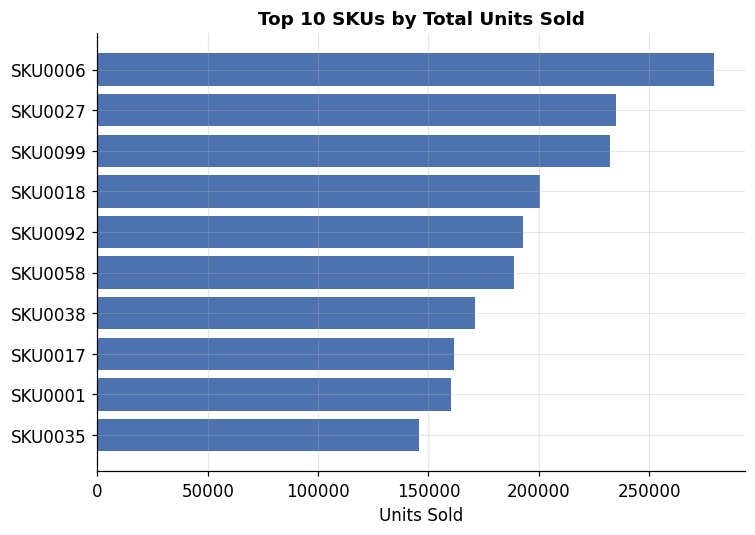

In [14]:
plot_top_products(df, "units_sold")

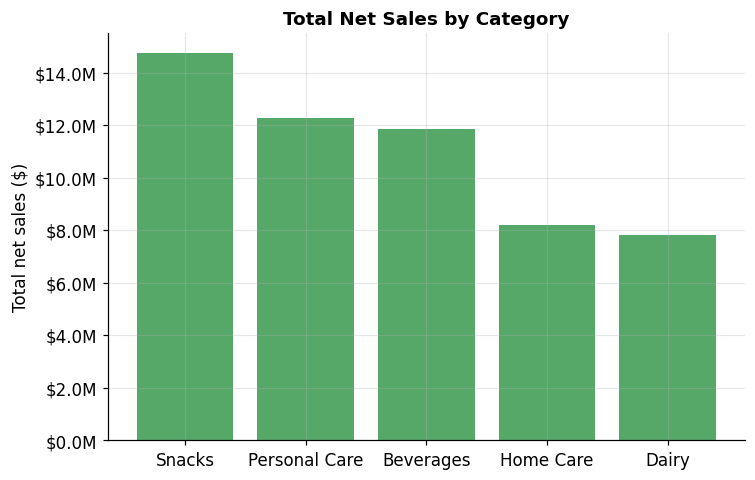

In [15]:
def plot_category_contribution(df: pd.DataFrame) -> None:
    """Bar chart of total net_sales contribution by category."""
    category_totals = df.groupby("category")["net_sales"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(category_totals.index, category_totals.values, color="#55A868")
    ax.set_title("Total Net Sales by Category", fontsize=12, fontweight="bold")
    ax.set_ylabel("Total net sales ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
    fig.tight_layout()
    plt.show()

plot_category_contribution(df)

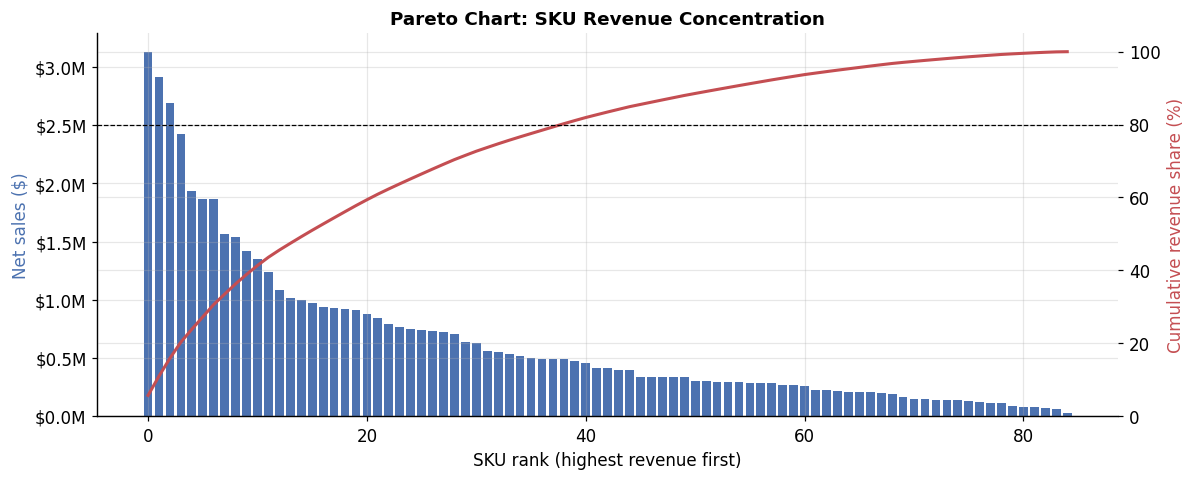

SKUs needed to reach 80% of total revenue: 39 of 85


In [16]:
def plot_pareto(df: pd.DataFrame) -> None:
    """Pareto chart: SKUs ranked by revenue (bars) with cumulative
    revenue share overlaid (line), to see how concentrated revenue is
    across the 91 SKUs.
    """
    sku_revenue = df.groupby("sku_id")["net_sales"].sum().sort_values(ascending=False)
    cumulative_share = sku_revenue.cumsum() / sku_revenue.sum() * 100

    fig, ax1 = plt.subplots(figsize=(11, 4.5))
    ax1.bar(range(len(sku_revenue)), sku_revenue.values, color="#4C72B0")
    ax1.set_xlabel("SKU rank (highest revenue first)")
    ax1.set_ylabel("Net sales ($)", color="#4C72B0")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))

    ax2 = ax1.twinx()
    ax2.plot(range(len(cumulative_share)), cumulative_share.values, color="#C44E52", linewidth=2)
    ax2.axhline(80, color="black", linestyle="--", linewidth=0.8)
    ax2.set_ylabel("Cumulative revenue share (%)", color="#C44E52")
    ax2.set_ylim(0, 105)

    ax1.set_title("Pareto Chart: SKU Revenue Concentration", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

    skus_to_80pct = (cumulative_share <= 80).sum() + 1
    print(f"SKUs needed to reach 80% of total revenue: {skus_to_80pct} of {len(sku_revenue)}")

plot_pareto(df)

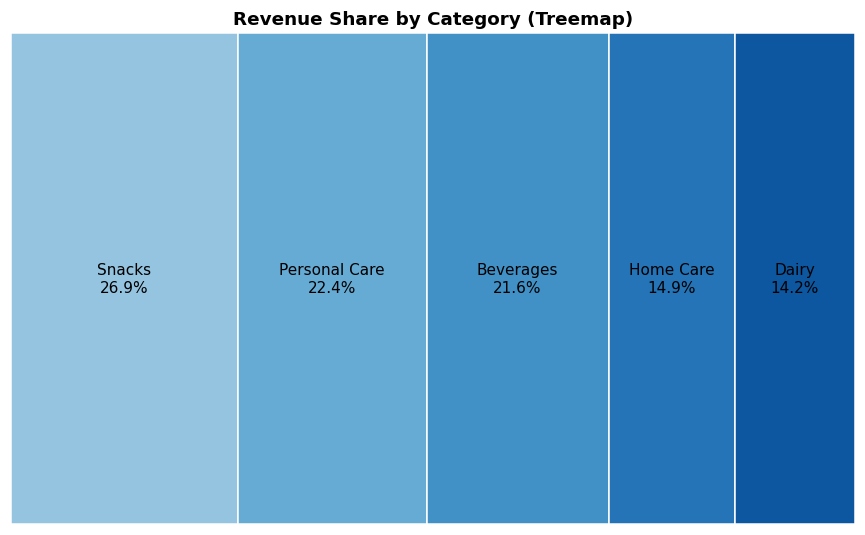

In [17]:
def plot_category_treemap(df: pd.DataFrame) -> None:
    """Simple row-based treemap of revenue share by category (no external
    treemap library required). Rectangle area is proportional to each
    category\'s share of total net_sales.
    """
    category_totals = df.groupby("category")["net_sales"].sum().sort_values(ascending=False)
    shares = category_totals / category_totals.sum()

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(shares)))
    x_cursor = 0.0
    for (label, share), color in zip(shares.items(), colors):
        width = share
        ax.add_patch(Rectangle((x_cursor, 0), width, 1, facecolor=color, edgecolor="white"))
        ax.text(x_cursor + width / 2, 0.5, f"{label}\n{share*100:.1f}%",
                ha="center", va="center", fontsize=10, color="black")
        x_cursor += width

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title("Revenue Share by Category (Treemap)", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_category_treemap(df)

**Commentary:** revenue is not evenly spread across all 91 SKUs -- the Pareto chart shows a meaningful share of total revenue concentrated in a subset of SKUs, though not an extreme 80/20 split. Category contribution looks fairly balanced overall rather than dominated by a single category, based on both the bar chart and the treemap. The top-revenue and top-units SKU lists differ somewhat, suggesting some products sell in high volume at lower price points while others sell fewer units at a higher price -- worth keeping in mind rather than assuming revenue and volume rankings track each other. No product was flagged here as obviously volatile without a formal volatility measure, which belongs in Notebook 03.

# 7. Store Exploration

In [18]:
def store_comparison_table(df: pd.DataFrame) -> pd.DataFrame:
    """Revenue, units, average daily sales, variance, and coefficient of
    variation, by store.
    """
    daily_by_store = df.groupby(["store_id", "date"])["net_sales"].sum().reset_index()
    summary = df.groupby("store_id").agg(
        total_revenue=("net_sales", "sum"),
        total_units=("units_sold", "sum"),
    )
    daily_stats = daily_by_store.groupby("store_id")["net_sales"].agg(["mean", "var", "std"])
    daily_stats["cov"] = daily_stats["std"] / daily_stats["mean"]
    summary = summary.join(daily_stats.rename(columns={"mean": "avg_daily_sales", "var": "daily_variance", "std": "daily_std"}))
    return summary.round(2)

store_table = store_comparison_table(df)
store_table

,total_revenue,total_units,avg_daily_sales,daily_variance,daily_std,cov
store_id,,,,,,
STORE0001,41939805.83,5681442.0,38301.19,17654235.00,4201.69,0.11
STORE0002,12929146.33,1594854.0,11807.44,2264787.16,1504.92,0.13


/tmp/ipykernel_1145/3263820570.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot(data, labels=["STORE0001", "STORE0002"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})


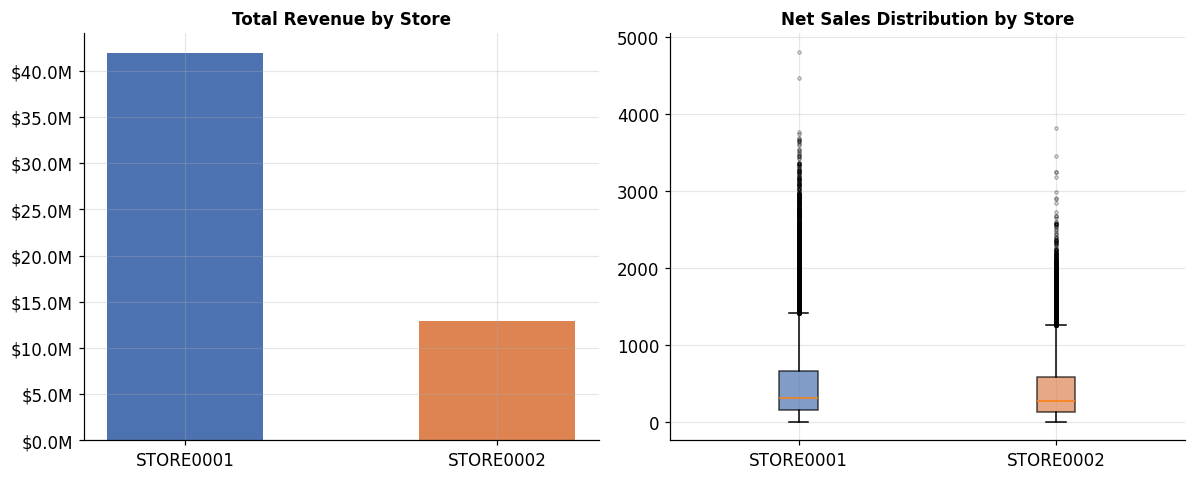

In [19]:
def plot_store_comparison(df: pd.DataFrame) -> None:
    """Bar chart of total revenue by store, and boxplot of net_sales by
    store, side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    revenue_by_store = df.groupby("store_id")["net_sales"].sum()
    axes[0].bar(revenue_by_store.index, revenue_by_store.values, color=["#4C72B0", "#DD8452"], width=0.5)
    axes[0].set_title("Total Revenue by Store", fontsize=11, fontweight="bold")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))

    data = [df.loc[df["store_id"] == s, "net_sales"] for s in ["STORE0001", "STORE0002"]]
    box = axes[1].boxplot(data, labels=["STORE0001", "STORE0002"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})
    for patch, color in zip(box["boxes"], ["#4C72B0", "#DD8452"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title("Net Sales Distribution by Store", fontsize=11, fontweight="bold")

    fig.tight_layout()
    plt.show()

plot_store_comparison(df)

**Commentary:** STORE0001 shows higher total revenue and a higher average daily sales figure than STORE0002, which is expected given it also carries more SKUs. The coefficient of variation for daily sales looks broadly similar between the two stores rather than dramatically different, based on the table above. These are descriptive differences only -- no inference is drawn about why the stores differ, and no significance claim is made.

# 8. Weather Exploration

Note: this dataset contains temperature and rainfall fields; no humidity field is present, so humidity is not explored here.

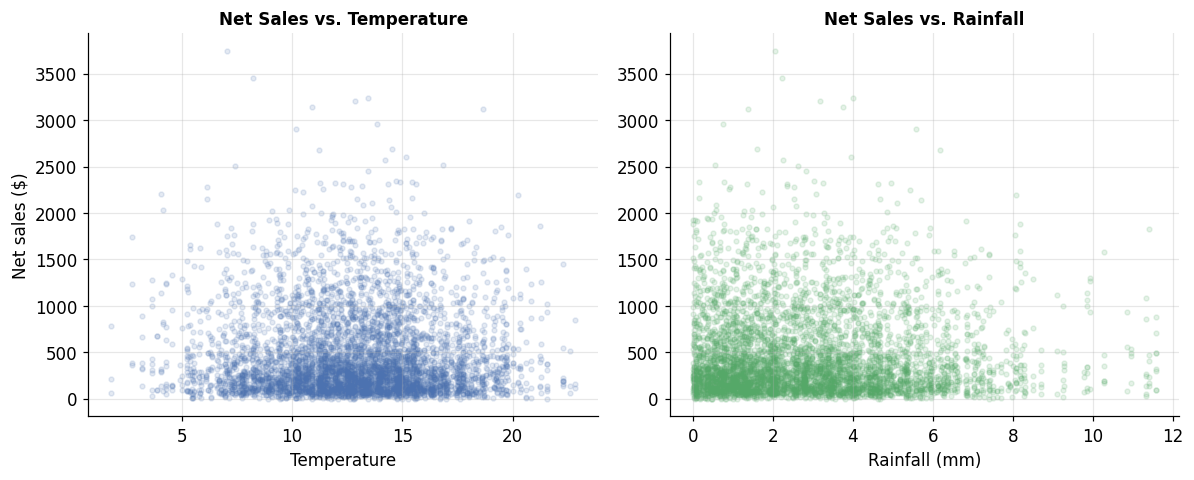

In [20]:
def plot_weather_scatter(df: pd.DataFrame) -> None:
    """Scatterplots of net_sales against temperature and against
    rainfall.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    sample = df.sample(5000, random_state=42)  # sampled for a readable scatter, not a statistical choice
    axes[0].scatter(sample["temperature"], sample["net_sales"], alpha=0.15, s=10, color="#4C72B0")
    axes[0].set_title("Net Sales vs. Temperature", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Temperature")
    axes[0].set_ylabel("Net sales ($)")

    axes[1].scatter(sample["rain_mm"], sample["net_sales"], alpha=0.15, s=10, color="#55A868")
    axes[1].set_title("Net Sales vs. Rainfall", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Rainfall (mm)")

    fig.tight_layout()
    plt.show()

plot_weather_scatter(df)

In [21]:
weather_correlations = df[["net_sales", "temperature", "rain_mm"]].corr()["net_sales"].drop("net_sales")
weather_correlations.round(4)

,net_sales
temperature,-0.0045
rain_mm,0.0005


**Commentary:** both scatterplots show a flat, uncorrelated-looking cloud of points -- no visible upward or downward trend as temperature or rainfall changes. The simple correlation values are close to zero in both cases. Visually, weather looks weakly associated with sales at best -- worth confirming formally in Notebook 03 rather than dismissing outright, but nothing here suggests a strong relationship.

# 9. Correlation Exploration

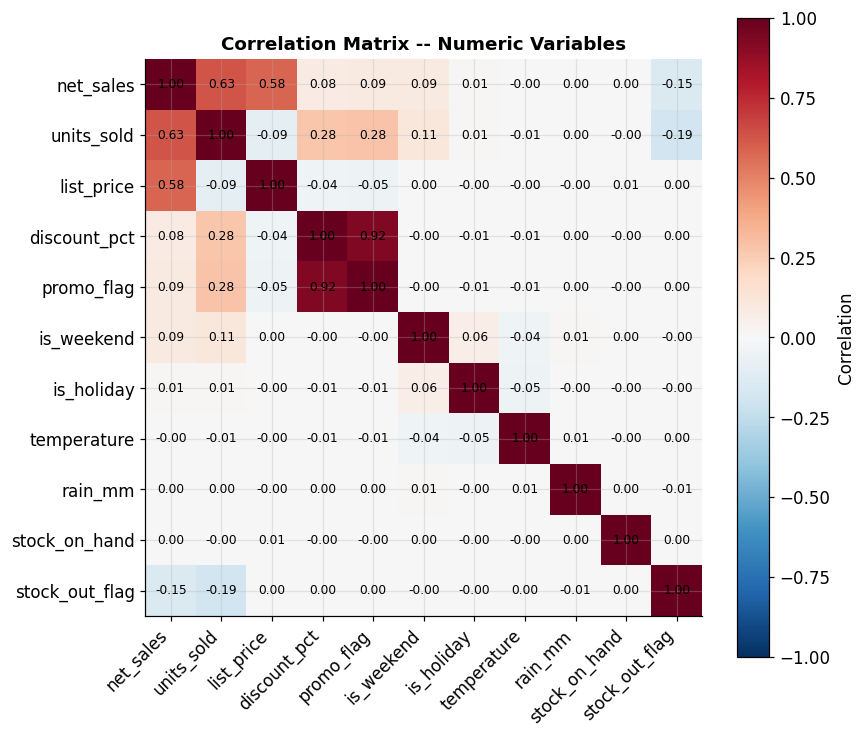

In [22]:
def plot_correlation_heatmap(df: pd.DataFrame) -> pd.DataFrame:
    """Correlation matrix and heatmap for the numeric variables most
    relevant to sales.
    """
    numeric_cols = ["net_sales", "units_sold", "list_price", "discount_pct",
                     "promo_flag", "is_weekend", "is_holiday", "temperature",
                     "rain_mm", "stock_on_hand", "stock_out_flag"]
    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_yticklabels(numeric_cols)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label="Correlation")
    ax.set_title("Correlation Matrix -- Numeric Variables", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()
    return corr_matrix

correlation_matrix = plot_correlation_heatmap(df)

**Commentary:** `units_sold` shows a strong positive correlation with `net_sales`, which is mechanical (more units sold directly drives more revenue) rather than an insight. `list_price` and `discount_pct` show weak-to-moderate correlations with `net_sales`. `promo_flag` shows a weak-to-moderate positive correlation. `temperature`, `rain_mm`, `is_holiday`, and `stock_out_flag` all sit close to zero -- weak by visual standard. No causal interpretation is made from any of these correlations -- a correlation here only marks a variable as worth testing formally, not as a confirmed driver.

# 10. Candidate Drivers

Based on the exploration above, the following variables appear likely to warrant formal testing in Notebook 03:

- **Promotion** -- promotion days visually show higher average and median sales (Section 5), and `promo_flag` shows a positive correlation with `net_sales` (Section 9).
- **Weekend** -- weekend average sales appear visibly higher than weekday averages (Section 4).
- **Season** -- monthly boxplots and averages show a recurring higher period around mid-year (Section 4).
- **Category** -- category-level revenue contribution differs, though not dramatically (Section 6).
- **Price (list_price)** -- shows a correlation with net_sales worth testing formally alongside other factors (Section 9).
- **Store** -- revenue, average daily sales, and dispersion look different between the two stores, though the gap does not look dramatic (Section 7).
- **Weather (temperature, rainfall)** -- shows a visually flat relationship with sales and near-zero correlation, making it a candidate for a formal "no effect" test rather than a candidate driver in the usual sense (Sections 8-9).

# 11. Hypotheses for Notebook 03

| ID | Candidate Hypothesis | Why EDA Suggests It | Planned Test (Notebook 03) |
|---|---|---|---|
| H1 | Promotion appears associated with higher sales | Higher average/median sales and a right-shifted distribution on promotion days (Section 5) | Notebook 03 |
| H2 | Weekend sales appear higher than weekday sales | Visibly higher weekend average in the bar chart comparison (Section 4) | Notebook 03 |
| H3 | Store volatility appears different between the two stores | Different variance/CoV figures in the store comparison table (Section 7) | Notebook 03 |
| H4 | Weather appears weakly (or not) associated with sales | Flat scatterplots and near-zero correlation with temperature and rainfall (Sections 8-9) | Notebook 03 |
| H5 | Seasonality appears present, with a mid-year peak | Monthly boxplot and bar chart both show a visibly elevated period around mid-year (Section 4) | Notebook 03 |
| H6 | Category appears associated with differences in sales volume | Category revenue contribution differs across categories (Section 6) | Notebook 03 |
| H7 | Price (list_price) appears associated with net sales | Correlation observed in the correlation matrix (Section 9) | Notebook 03 |

These are hypotheses only. None of them has been tested, and none should be treated as a conclusion at this stage.

# 12. EDA Summary

Sales appear right-skewed rather than symmetric, with a visible cluster of high-value days that may be linked to promotions. The daily sales trend does not look flat over the year -- a recurring mid-year elevation is visually consistent with a seasonal pattern, though demand generally appears reasonably stable rather than erratic. Promotion days appear to show higher sales on average, and weekends look higher than weekdays. Revenue appears moderately concentrated across SKUs rather than evenly spread, and category contribution looks fairly balanced. The two stores appear to differ somewhat in scale and dispersion, though not dramatically. Weather variables appear weakly associated with sales at best, based on both the scatterplots and the correlation matrix.

None of these observations should be read as proved, confirmed, significant, or causal -- they are visual and descriptive impressions only, intended to shortlist what is worth testing next.

These exploratory findings will be formally evaluated in Notebook 03.